In [1]:
import os
from titiler.eopf.reader import GeoZarrReader
from matplotlib.pyplot import imshow

In [2]:
os.environ["AWS_PROFILE"] = "eopf-explorer"
os.environ["AWS_ENDPOINT_URL"] = "https://s3.de.io.cloud.ovh.net/"

In [7]:
src_path = "s3:/esa-zarr-sentinel-explorer-fra/tests-output/sentinel-2-l2a/S2C_MSIL2A_20260117T101351_N0511_R022_T32TQM_20260117T135312.zarr"

In [8]:
with GeoZarrReader(src_path) as geozarr:
    print(geozarr)

GeoZarrReader(bounds=(11.393460776825856, 41.40403474566952, 12.76313643271526, 42.426911995520086), crs=CRS.from_epsg(4326), transform=None, height=None, width=None, input='s3:/esa-zarr-sentinel-explorer-fra/tests-output/sentinel-2-l2a/S2C_MSIL2A_20260117T101351_N0511_R022_T32TQM_20260117T135312.zarr', datatree=<xarray.DataTree>
Group: /
├── Group: /conditions
│   ├── Group: /conditions/geometry
│   │       Dimensions:                        (angle: 2, band: 13, y: 23, x: 23,
│   │                                           detector: 4)
│   │       Coordinates:
│   │         * angle                          (angle) <U7 56B 'zenith' 'azimuth'
│   │         * band                           (band) <U3 156B 'b00' 'b01' ... 'b11' 'b12'
│   │         * detector                       (detector) <U3 48B 'd09' 'd10' 'd11' 'd12'
│   │         * x                              (x) float32 92B 7e+05 7.05e+05 ... 8.1e+05
│   │         * y                              (y) float32 92B 4.7e+06 ... 4.59

In [9]:
with GeoZarrReader(src_path) as geozarr:
    print("Available Groups :", geozarr.groups)
    print("Available Variables :", geozarr.variables)

Available Groups : ['/measurements/reflectance', '/quality/atmosphere/r10m', '/quality/atmosphere/r20m', '/quality/atmosphere/r60m', '/quality/mask/r10m', '/quality/mask/r20m', '/quality/mask/r60m', '/quality/probability/r20m']
Available Variables : ['/measurements/reflectance:b01', '/measurements/reflectance:b02', '/measurements/reflectance:b03', '/measurements/reflectance:b04', '/measurements/reflectance:b05', '/measurements/reflectance:b06', '/measurements/reflectance:b07', '/measurements/reflectance:b08', '/measurements/reflectance:b09', '/measurements/reflectance:b11', '/measurements/reflectance:b12', '/measurements/reflectance:b8a', '/quality/atmosphere/r10m:aot', '/quality/atmosphere/r10m:wvp', '/quality/atmosphere/r20m:aot', '/quality/atmosphere/r20m:wvp', '/quality/atmosphere/r60m:aot', '/quality/atmosphere/r60m:wvp', '/quality/mask/r10m:b02', '/quality/mask/r10m:b03', '/quality/mask/r10m:b04', '/quality/mask/r10m:b08', '/quality/mask/r20m:b05', '/quality/mask/r20m:b06', '/qua

## GetInfo

In [12]:
with GeoZarrReader(src_path) as geozarr:
    # get Info for all available variables
    info = geozarr.info()

    info_b03 = geozarr.info(variables=["/measurements/reflectance:b03"])

print(list(info))
print(info_b03)

['/measurements/reflectance:b01', '/measurements/reflectance:b02', '/measurements/reflectance:b03', '/measurements/reflectance:b04', '/measurements/reflectance:b05', '/measurements/reflectance:b06', '/measurements/reflectance:b07', '/measurements/reflectance:b08', '/measurements/reflectance:b09', '/measurements/reflectance:b11', '/measurements/reflectance:b12', '/measurements/reflectance:b8a', '/quality/atmosphere/r10m:aot', '/quality/atmosphere/r10m:wvp', '/quality/atmosphere/r20m:aot', '/quality/atmosphere/r20m:wvp', '/quality/atmosphere/r60m:aot', '/quality/atmosphere/r60m:wvp', '/quality/mask/r10m:b02', '/quality/mask/r10m:b03', '/quality/mask/r10m:b04', '/quality/mask/r10m:b08', '/quality/mask/r20m:b05', '/quality/mask/r20m:b06', '/quality/mask/r20m:b07', '/quality/mask/r20m:b11', '/quality/mask/r20m:b12', '/quality/mask/r20m:b8a', '/quality/mask/r60m:b01', '/quality/mask/r60m:b09', '/quality/mask/r60m:b10', '/quality/probability/r20m:cld', '/quality/probability/r20m:snw']
{'/meas

## GetTile

In [13]:
with GeoZarrReader(src_path) as geozarr:
    minzoom, maxzoom = (
        geozarr.get_minzoom("/measurements/reflectance"),
        geozarr.get_maxzoom("/measurements/reflectance"),
    )
    center_lon = (geozarr.bounds[2] + geozarr.bounds[0]) / 2
    center_lat = (geozarr.bounds[3] + geozarr.bounds[1]) / 2

    print("MinZoom: ", minzoom)
    print("MaxZoom: ", maxzoom)
    print("Bounds: ", geozarr.bounds)

MinZoom:  7
MaxZoom:  14
Bounds:  (11.393460776825856, 41.40403474566952, 12.76313643271526, 42.426911995520086)


Tile(x=68, y=47, z=7)


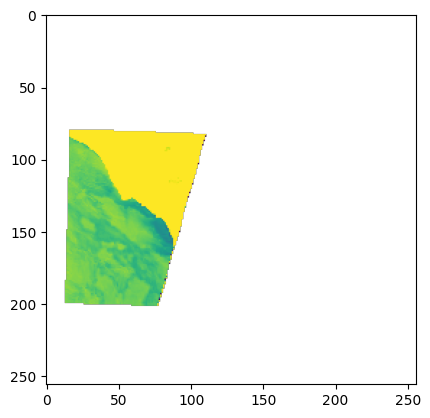

In [15]:
with GeoZarrReader(src_path) as geozarr:
    tile = geozarr.tms.tile(center_lon, center_lat, minzoom)
    print(tile)

    red = "/measurements/reflectance:b04"
    nir = "/measurements/reflectance:b8a"
    expression = f"({nir}-{red})/({nir}+{red})"

    img = geozarr.tile(
        *tile,
        expression=expression,
    )
    img.rescale(((-1, 0.1),))

imshow(img.data_as_image())

Tile(x=68, y=47, z=7)


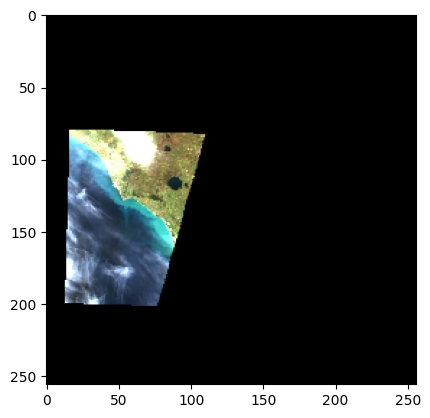

In [16]:
with GeoZarrReader(src_path) as geozarr:
    tile = geozarr.tms.tile(center_lon, center_lat, minzoom)
    print(tile)
    img = geozarr.tile(
        *tile,
        variables=[
            "/measurements/reflectance:b04",
            "/measurements/reflectance:b03",
            "/measurements/reflectance:b02",
        ],
    )
    img.rescale(((0, 0.1),))
imshow(img.data_as_image())

Tile(x=8741, y=6087, z=14)


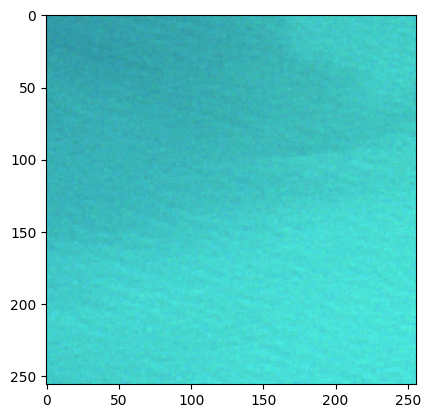

In [17]:
with GeoZarrReader(src_path) as geozarr:
    tile = geozarr.tms.tile(center_lon, center_lat, maxzoom)
    print(tile)
    img = geozarr.tile(
        *tile,
        variables=[
            "/measurements/reflectance:b04",
            "/measurements/reflectance:b03",
            "/measurements/reflectance:b02",
        ],
    )
    img.rescale(((0, 0.1),))
imshow(img.data_as_image())